# Supplementary figures

Each figure is one self-contained cell: it imports what it needs, loads saved data from
`data/generated/`, and writes a PDF to `figures/`. No simulations run here; each caption
names the generator that produces its data (`make data` runs them all).

Each cell is mirrored verbatim in the script named on its first line, so `make figures`
produces the same PDFs without Jupyter. After editing a cell here, run `make figure-scripts`.

## Figure S1: Payoffs over time

Data: `agent_uniform.npz`, `agent_variable.npz` from `scripts/generate/agent_main_data.py` (payoffs are computed from the saved snapshots).

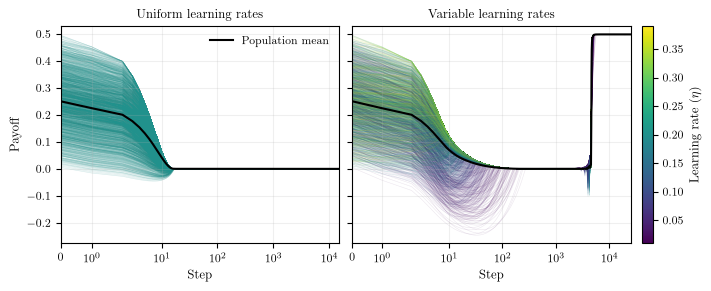

In [1]:
# Figure S1 (scripts/figures/figS01_population_payoffs.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style


def individual_payoffs(agents, b, c):
    """Mean payoff b * (partner cooperation) - c * (own cooperation), self-play included."""
    p, q = agents.T
    r = p - q
    own = np.empty(len(agents))
    received = np.zeros(len(agents))
    for start in range(0, len(agents), 250):  # blocks avoid an N x N matrix
        block = slice(start, start + 250)
        r_i = r[block, None]
        cooperation = (q[block, None] + r_i * q[None, :]) / (1 - r_i * r[None, :])
        own[block] = cooperation.mean(axis=1)
        received += cooperation.sum(axis=0) / len(agents)
    return b * received - c * own


runs = {}
for regime in ("uniform", "variable"):
    with np.load(DATA_DIR / f"agent_{regime}.npz") as data:
        assert bool(data["self_interactions"])
        b, c = float(data["b"]), float(data["c"])
        payoffs = np.array([individual_payoffs(state, b, c) for state in data["agents"]])
        runs[regime] = data["steps"], payoffs, data["eta"]

configure_paper_style()
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, 2.8), sharey=True)
cmap, norm = plt.get_cmap("viridis"), plt.Normalize(vmin=0.01, vmax=0.39)
low = min(payoffs.min() for _, payoffs, _ in runs.values())
high = max(payoffs.max() for _, payoffs, _ in runs.values())
padding = 0.04 * (high - low)

for ax, (regime, (steps, payoffs, eta)) in zip(axes, runs.items(), strict=True):
    lines = ax.plot(steps, payoffs, linewidth=0.4, alpha=0.10, zorder=1, rasterized=True)
    for line, rate in zip(lines, eta, strict=True):
        line.set_color(cmap(norm(rate)))
    ax.plot(steps, payoffs.mean(axis=1), color="black", linewidth=1.5, zorder=3,
            label="Population mean")
    ax.set(title=f"{regime.capitalize()} learning rates", xlabel="Step",
           xlim=(steps[0], steps[-1]), ylim=(low - padding, high + padding))
    ax.set_xscale("symlog")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Payoff")
axes[0].legend(frameon=False)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, pad=0.02,
             label=r"Learning rate $(\eta)$")
fig.savefig(FIGURES_DIR / "average_population_welfare.pdf")

## Figure S2: Infinite-population (lattice) model

Data: `lattice_uniform.npz`, `lattice_variable.npz` from `scripts/generate/lattice_data.py`, starting from a uniform density (equal mass at every grid point). Shaded bands contain the central 99.9%, 80%, 60%, 40% and 20% of the mass; the black line is the mean.

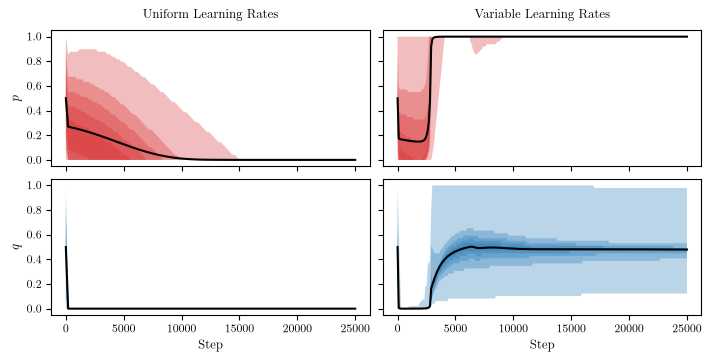

In [2]:
# Figure S2 (scripts/figures/figS02_lattice_dynamics.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style, tsplot_freq

configure_paper_style()
fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH, 3.5), sharex=True, sharey=True)
for column, (regime, title) in enumerate(
    [("uniform", "Uniform Learning Rates"), ("variable", "Variable Learning Rates")]
):
    with np.load(DATA_DIR / f"lattice_{regime}.npz") as data:
        steps, epsilon = data["steps"], float(data["epsilon"])
        # freq has shape (p point, q point, learning-rate grid, saved step).
        mass = data["freq"].sum(axis=2)
    grid = np.linspace(epsilon, 1 - epsilon, mass.shape[0])  # the lattice's grid points
    tsplot_freq(steps, grid, mass.sum(axis=1), color="C3", ax=axes[0, column])
    tsplot_freq(steps, grid, mass.sum(axis=0), color="C0", ax=axes[1, column])
    axes[0, column].set_title(title, pad=9)
    axes[1, column].set_xlabel("Step")
axes[0, 0].set_ylabel(r"$p$")
axes[1, 0].set_ylabel(r"$q$")

fig.savefig(FIGURES_DIR / "continuous_over_time.pdf", dpi=300)

## Figure S3: Distribution of $p$ on first reaching $q=\varepsilon$, and distributions certified by Theorem 1

Data: `axis_entry.npz` from `scripts/generate/axis_entry_data.py` (requires `agent_*.npz`). The generator fixes a 35% ALLD atom and solves for the uniform endpoint $p_{\max}$ with $-U = 0.001$, and for the Beta$(a, 1)$ shape with $P-Q = 0.001$; the cell re-checks both margins by numerical integration.

ALLD example: 35.0% atom at epsilon + uniform on [epsilon, 0.720871]
ALLD example: P=0.035937563, Q=0.306678632, U=-0.001000000, P-Q=-0.270741068; certificate: ALLD
TFT example: P=0.186351315, Q=0.185351315, U=188.259919471, P-Q=0.001000000; certificate: TFT


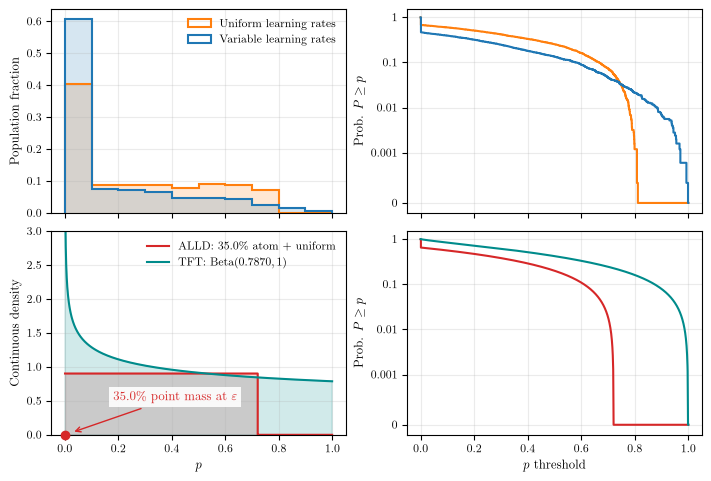

In [3]:
# Figure S3 (scripts/figures/figS03_axis_entry_distribution.py)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, uniform

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style
from reactive_learning.transient_unforgiving import convergence_bounds

with np.load(DATA_DIR / "axis_entry.npz") as data:
    conditions, agents = data["conditions"], data["agents"]
    epsilon, b, c = (float(data[key]) for key in ("epsilon", "b", "c"))
    fraction, p_max = float(data["fraction_alld"]), float(data["p_max"])
    fraction_tft, beta_shapes = float(data["fraction_tft"]), data["beta_shapes"]
    target_margin = float(data["certificate_margin"])
    p_grid, survival = data["p_grid"], data["theoretical_survival"]

# Example distributions (bottom row), each certified by Theorem 1 with margin 0.001.
examples = (
    ("ALLD", uniform(loc=epsilon, scale=p_max - epsilon), fraction),
    ("TFT", beta(*beta_shapes, loc=epsilon, scale=1 - 2 * epsilon), fraction_tft),
)
print(f"ALLD example: {100 * fraction:.1f}% atom at epsilon + uniform on [epsilon, {p_max:.6f}]")
for expected, distribution, atom_mass in examples:
    bounds = convergence_bounds(distribution, b=b, c=c, epsilon=epsilon, atom_mass=atom_mass)
    print(f"{expected} example: P={bounds.positive:.9f}, Q={bounds.negative:.9f}, "
          f"U={-bounds.alld_margin:.9f}, P-Q={bounds.tft_margin:.9f}; "
          f"certificate: {bounds.outcome}")
    margin = bounds.alld_margin if expected == "ALLD" else bounds.tft_margin
    assert bounds.outcome == expected and np.isclose(margin, target_margin, atol=1e-10)

configure_paper_style()
fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH, 4.7), sharex="col")
axes[1, 1].sharey(axes[0, 1])

# Top row: empirical p at the first step with every agent on q = epsilon.
colors = {"Uniform learning rates": "C1", "Variable learning rates": "C0"}
bins = np.linspace(epsilon, 1 - epsilon, 11)
for condition, state in zip(conditions, agents, strict=True):
    label, color = str(condition), colors[str(condition)]
    weights = np.full(len(state), 1 / len(state))
    axes[0, 0].hist(state[:, 0], bins=bins, weights=weights, histtype="stepfilled",
                    color=color, alpha=0.18)
    axes[0, 0].hist(state[:, 0], bins=bins, weights=weights, histtype="step", color=color,
                    linewidth=1.5, label=label)
    sorted_p = np.sort(state[:, 0])
    thresholds = np.unique(np.r_[0.0, sorted_p, 1.0])
    empirical_survival = 1 - np.searchsorted(sorted_p, thresholds, side="left") / len(sorted_p)
    axes[0, 1].step(thresholds, empirical_survival, where="pre", linewidth=1.5, color=color,
                    label=label)

# Bottom row: densities of the continuous parts (atoms marked at the baseline).
# The grid approaches the Beta's integrable singularity at epsilon without evaluating it.
density_grid = np.unique(np.r_[
    epsilon + (1 - 2 * epsilon) * np.geomspace(1e-8, 1, 500),
    np.linspace(epsilon + 1e-8, 1 - epsilon, 2000),
    p_max,
    np.nextafter(p_max, np.inf),
])
labels = (
    rf"ALLD: {100 * fraction:.1f}\% atom + uniform",
    "TFT: " + (rf"{100 * fraction_tft:.2f}\% atom + " if fraction_tft else "")
    + rf"Beta$({beta_shapes[0]:.4f}, {beta_shapes[1]:g})$",
)
for (_, distribution, atom_mass), curve, color, label in zip(
    examples, survival, ("C3", "#008b8b"), labels, strict=True
):
    density = (1 - atom_mass) * distribution.pdf(density_grid)
    axes[1, 0].fill_between(density_grid, density, color=color, alpha=0.18)
    axes[1, 0].plot(density_grid, density, linewidth=1.5, color=color, label=label)
    if atom_mass:
        axes[1, 0].plot(epsilon, 0, "o", color=color, clip_on=False, zorder=5)
        axes[1, 0].annotate(
            rf"{100 * atom_mass:.1f}\% point mass at $\varepsilon$",
            xy=(epsilon, 0), xytext=(0.21, 0.17), textcoords="axes fraction", color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9, "pad": 3},
            arrowprops={"arrowstyle": "->", "color": color, "shrinkA": 4, "shrinkB": 7},
        )
    axes[1, 1].plot(p_grid, curve, linewidth=1.5, color=color, label=label)

for row in range(2):
    axes[row, 0].set(xlabel=r"$p$" if row == 1 else "",
                     ylabel="Population fraction" if row == 0 else "Continuous density",
                     xlim=(-0.05, 1.05), ylim=(0, None))
    ax = axes[row, 1]
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.set(xlim=(-0.05, 1.05), ylim=(-0.0002, 1.5), xlabel=r"$p$ threshold" if row == 1 else "",
           ylabel=r"Prob. $P\geq p$")
    ax.set_yticks([0, 1e-3, 1e-2, 1e-1, 1], ["0", "0.001", "0.01", "0.1", "1"])
axes[1, 0].set_ylim(0, 3)
for ax in axes.flat:
    ax.grid(alpha=0.25)
for ax in axes[:, 0]:
    ax.legend(loc="upper right", frameon=False)
fig.savefig(FIGURES_DIR / "axis_entry_p_distribution.pdf")

## Figure S4: Which distributions on $q=\varepsilon$ Theorem 1 certifies

Data: `convergence_phase_diagrams.npz` from `scripts/generate/convergence_phase_diagrams_data.py`.

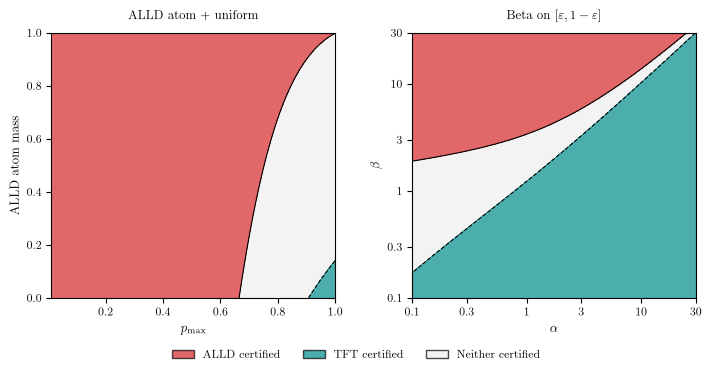

In [4]:
# Figure S4 (scripts/figures/figS04_certificate_phase_diagrams.py)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

# Margins -U (ALLD certificate) and P - Q (TFT certificate) on two parameter grids.
with np.load(DATA_DIR / "convergence_phase_diagrams.npz") as data:
    sign_tolerance = float(data["sign_tolerance"])
    panels = [
        (data["p_max_values"], data["atom_masses"], data["mixture_alld"], data["mixture_tft"],
         "ALLD atom + uniform", r"$p_{\max}$", "ALLD atom mass", False),
        (data["beta_shapes"], data["beta_shapes"], data["full_beta_alld"], data["full_beta_tft"],
         r"Beta on $[\varepsilon,1-\varepsilon]$", r"$\alpha$", r"$\beta$", True),
    ]

configure_paper_style()
colors = ["#eeeeee", "C3", "#008b8b"]  # neither, ALLD, TFT
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, 3.6))
fig.get_layout_engine().set(wspace=0.08)
for ax, (x, y, alld_margin, tft_margin, title, xlabel, ylabel, log_axes) in zip(
    axes, panels, strict=True
):
    fields = [(-np.maximum(alld_margin, tft_margin), colors[0], -sign_tolerance),
              (alld_margin, colors[1], sign_tolerance),
              (tft_margin, colors[2], sign_tolerance)]
    for field, color, threshold in fields:
        if field.max() > threshold:
            ax.contourf(x, y, field, levels=[threshold, field.max() + 1], colors=[color],
                        alpha=0.7, antialiased=False)
    # Solid line: U = 0. Dashed line: P - Q = 0.
    for margin, style in zip((alld_margin, tft_margin), ["-", "--"], strict=True):
        if margin.min() < 0 < margin.max():
            ax.contour(x, y, margin, levels=[0], colors="black", linewidths=0.8, linestyles=style)
    ax.set(xlabel=xlabel, ylabel=ylabel, xlim=(x[0], x[-1]), ylim=(y[0], y[-1]))
    ax.set_title(title, pad=10)
    if log_axes:
        ticks = [0.1, 0.3, 1, 3, 10, 30]
        ax.set(xscale="log", yscale="log")
        ax.set_xticks(ticks, [str(t) for t in ticks])
        ax.set_yticks(ticks, [str(t) for t in ticks])
        ax.minorticks_off()
    else:
        ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1])

legend = fig.legend(
    handles=[
        Patch(facecolor=colors[i], edgecolor="k", label=label)
        for i, label in [(1, "ALLD certified"), (2, "TFT certified"), (0, "Neither certified")]
    ],
    loc="outside lower center", ncol=3, frameon=False,
)
for handle in legend.legend_handles:
    handle.set_alpha(0.7)
fig.savefig(FIGURES_DIR / "convergence_phase_diagrams.pdf")

## Figure S5: Agents leave the unforgiving line in order of learning rate

Data: `agent_variable.npz` from `scripts/generate/agent_main_data.py`.

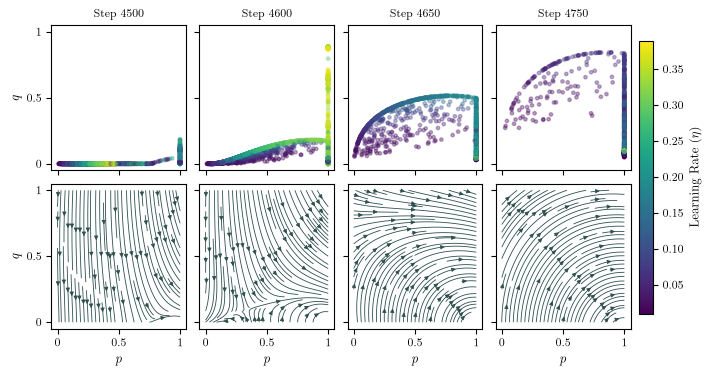

In [5]:
# Figure S5 (scripts/figures/figS05_gtft_transition.py)
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import configure_paper_style, plot_agents_and_avg_field_2x4

STEPS = (4500, 4600, 4650, 4750)

with np.load(DATA_DIR / "agent_variable.npz") as data:
    steps = data["steps"].tolist()
    snapshots = [data["agents"][steps.index(step)] for step in STEPS]
    eta, b, c = data["eta"], float(data["b"]), float(data["c"])

configure_paper_style()
fig, axs = plot_agents_and_avg_field_2x4(
    snapshots, [f"Step {step}" for step in STEPS], eta, b=b, c=c
)
fig.savefig(FIGURES_DIR / "steps_with_streams_GTFT.pdf")

## Figure S6: Long-run continuation of a reduced, reweighted variable-rate population

Data: `agent_variable_long_run_n125_rate100.npz` from `scripts/generate/agent_variable_long_run_data.py` (requires `agent_variable.npz` and a C compiler; about 3.6 h). 125 weighted agents, learning rates $\times 100$, $10^{10}$ updates.

Completed 10,000,000,000 / 10,000,000,000 additional updates; N = 125.


min p:  0.9989937797950521 | max p:  0.999
min q:  0.4989943254760954 | max q:  0.5020896272392731


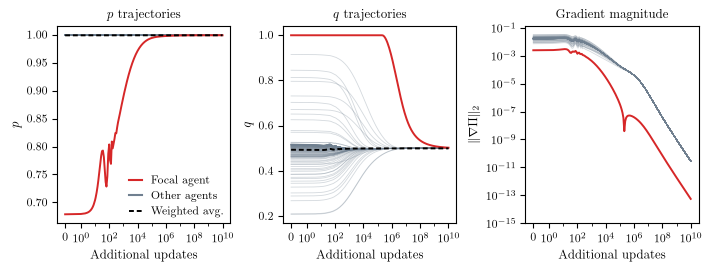

In [6]:
# Figure S6 (scripts/figures/figS06_long_run.py)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

with np.load(DATA_DIR / "agent_variable_long_run_n125_rate100.npz") as data:
    steps, agents, weights = data["steps"], data["agents"], data["weights"]
    b, c = float(data["b"]), float(data["c"])
    focal = int(data["special_count"])  # agents [:focal] started off the p = 1 - epsilon line
    requested = int(data["requested_steps"])
print(f"Completed {steps[-1]:,} / {requested:,} additional updates; N = {len(weights)}.")

# Weighted payoff-gradient magnitude, before learning-rate scaling or projection.
gradient_magnitudes = np.empty(agents.shape[:2])
for frame, state in enumerate(agents):
    p, q = state.T
    pi, qi, pj, qj = p[:, None], q[:, None], p[None, :], q[None, :]
    denom = (1 + pj * qi - qi * qj + pi * (-pj + qj)) ** 2
    common = c + b * (-pj + qj)
    gp = (-(pj * qi + qj - qi * qj) * common / denom) @ weights
    gq = (((qj - 1) + pi * (pj - qj)) * common / denom) @ weights
    gradient_magnitudes[frame] = np.hypot(gp, gq)

p, q = agents[-1].T
print("min p: ", p.min(), "| max p: ", p.max())
print("min q: ", q.min(), "| max q: ", q.max())

configure_paper_style()
fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 2.6))
for coordinate, (ax, name) in enumerate(zip(axes[:2], ["p", "q"], strict=True)):
    ax.plot(steps, agents[:, focal:, coordinate], color="slategrey", alpha=0.3, lw=0.6)
    ax.plot(steps, agents[:, :focal, coordinate], color="tab:red", lw=1.4)
    ax.plot([], [], color="tab:red", label="Focal agent")
    ax.plot([], [], color="slategrey", label="Other agents")
    # Short dashes, so two whole dashes fit in the short legend sample below.
    ax.plot(steps, agents[:, :, coordinate] @ weights, color="black", ls=(0, (2.5, 1.5)), lw=1.4,
            label="Weighted avg.")
    ax.set_xscale("symlog", linthresh=1)
    ax.xaxis.get_major_locator().set_params(numticks=6)
    ax.set(xlabel="Additional updates", ylabel=rf"${name}$", title=rf"${name}$ trajectories")
# Lower-right corner, clear of the focal agent's rise near 10^2 updates.
axes[0].legend(loc="lower right", borderaxespad=0.2, handlelength=1.2, frameon=False)

ax = axes[2]
ax.plot(steps, gradient_magnitudes[:, focal:], color="slategrey", alpha=0.3, linewidth=0.6)
ax.plot(steps, gradient_magnitudes[:, :focal], color="tab:red", linewidth=1.4)
ax.set_xscale("symlog", linthresh=1)
ax.xaxis.get_major_locator().set_params(numticks=6)
ax.set_yscale("log")
ax.set_ylim(1e-15, None)
ax.yaxis.set_major_locator(ticker.FixedLocator([10.0**e for e in range(-1, -16, -2)]))
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set(xlabel="Additional updates", ylabel=r"$\|\nabla \Pi\|_2$", title="Gradient magnitude")
fig.savefig(FIGURES_DIR / "long_run_traj.pdf", dpi=300)

## Figure S7: Recovery from a small $q$ perturbation of GTFT

Data: `gtft_q_shock.npz` from `scripts/generate/gtft_q_shock_data.py`.

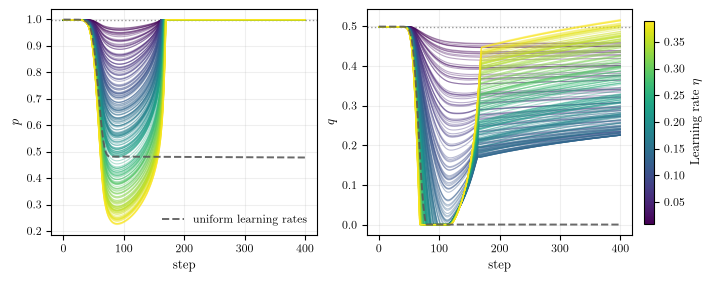

In [7]:
# Figure S7 (scripts/figures/figS07_gtft_q_shock.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

with np.load(DATA_DIR / "gtft_q_shock.npz") as data:
    steps, agents, eta = data["steps"], data["agents"], data["eta"]
    regimes = data["rate_regimes"].tolist()
    p_gtft = 1 - float(data["epsilon"])
    q_gtft = p_gtft - float(data["c"]) / float(data["b"])
variable, uniform = regimes.index("variable"), regimes.index("uniform")

configure_paper_style()
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, 2.7))
norm, cmap = plt.Normalize(vmin=0.01, vmax=0.39), plt.cm.viridis
for ax, (label, k, gtft_value) in zip(axes, [("$p$", 0, p_gtft), ("$q$", 1, q_gtft)], strict=True):
    # With a shared rate, identical agents stay identical: one line is the whole population.
    ax.plot(steps, agents[uniform][:, 0, k], color="0.35", linestyle="--", linewidth=1.4,
            alpha=0.9, zorder=10, label="uniform learning rates")
    for i in np.argsort(eta[variable]):  # fastest learners drawn last, on top
        ax.plot(steps, agents[variable][:, i, k], color=cmap(norm(eta[variable][i])), alpha=0.36,
                linewidth=0.8, zorder=2)
    ax.axhline(gtft_value, color="0.6", linestyle=":", linewidth=1, zorder=0)
    ax.set(xlabel="step", ylabel=label)
    ax.grid(alpha=0.2)
axes[0].legend(loc="lower right", frameon=False)
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=axes, label=r"Learning rate $\eta$",
             shrink=0.9, pad=0.02)
fig.savefig(FIGURES_DIR / "gtft_perturbation_trajectories_q_infinitesimal.pdf")

## Figure S8: Recovery from independent half-disk displacements of GTFT

Data: `gtft_disk_displacement.npz` from `scripts/generate/gtft_disk_displacement_data.py`. The printed counts check every replicate's endpoint (Sec. III D).

variable: 500/500 populations have every agent at p = 1 - epsilon at step 500 (atol=1e-10).
uniform: 500/500 populations have every agent at q = epsilon and p < 1/2 at step 500 (atol=1e-10).


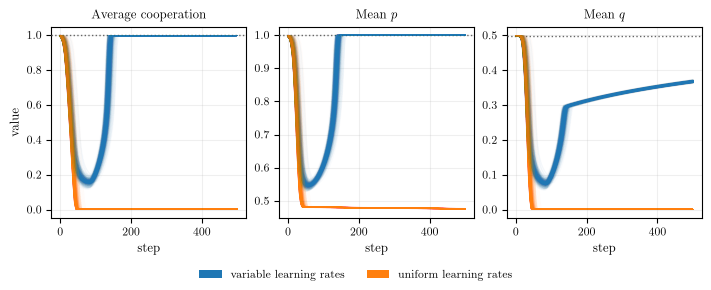

In [8]:
# Figure S8 (scripts/figures/figS08_gtft_disk_displacement.py)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

METRICS = {"cooperation": "Average cooperation", "mean_p": "Mean $p$", "mean_q": "Mean $q$"}
COLORS = {"variable": "tab:blue", "uniform": "tab:orange"}

with np.load(DATA_DIR / "gtft_disk_displacement.npz") as data:
    steps, regimes = data["steps"], [str(regime) for regime in data["rate_regimes"]]
    histories = {regime: {key: data[key][i] for key in METRICS} for i, regime in enumerate(regimes)}
    final_agents, final_step = data["final_agents"], int(data["simulation_steps"])
    radius, epsilon = float(data["displacement_radius"]), float(data["epsilon"])
    p_gtft = 1 - epsilon
    q_gtft = p_gtft - float(data["c"]) / float(data["b"])

# Endpoint of every replicate: variable-rate populations back on p = 1 - epsilon;
# uniform-rate populations on q = epsilon with p < 1/2 (Theorem 1 then gives ALLD).
ATOL = 1e-10
for regime, agents in zip(regimes, final_agents, strict=True):
    if regime == "variable":
        passed = np.all(np.abs(agents[:, :, 0] - p_gtft) <= ATOL, axis=1)
        target = "every agent at p = 1 - epsilon"
    else:
        passed = np.all(np.abs(agents[:, :, 1] - epsilon) <= ATOL, axis=1) & np.all(
            agents[:, :, 0] < 0.5, axis=1
        )
        target = "every agent at q = epsilon and p < 1/2"
    print(f"{regime}: {passed.sum()}/{len(passed)} populations have {target} "
          f"at step {final_step} (atol={ATOL:g}).")

configure_paper_style()
fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 2.8), sharex=True)
references = {"cooperation": 1.0, "mean_p": p_gtft, "mean_q": q_gtft}
for ax, (metric, title) in zip(axes, METRICS.items(), strict=True):
    for regime in ("variable", "uniform"):
        values = histories[regime][metric]  # (replicate, saved step)
        for row in values:
            ax.plot(steps, row, color=COLORS[regime], alpha=min(1.0, max(0.025, 6 / len(values))),
                    linewidth=0.8, zorder=5)
    ax.axhline(references[metric], color="0.4", linestyle=":", linewidth=1, zorder=3)
    ax.set(title=title, xlabel="step")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("value")
fig.legend(
    handles=[Patch(facecolor=COLORS[regime], edgecolor="none", label=f"{regime} learning rates")
             for regime in ("variable", "uniform")],
    loc="outside lower center", ncol=2, frameon=False,
)
fig.savefig(FIGURES_DIR / f"gtft_perturbation_disk_displacement_r{radius:g}_lines.pdf")

## Figure S9: Robustness to benefit-to-cost ratio, learning-rate heterogeneity and population size

Data: `basin.npz` from `scripts/generate/basin_data.py`.

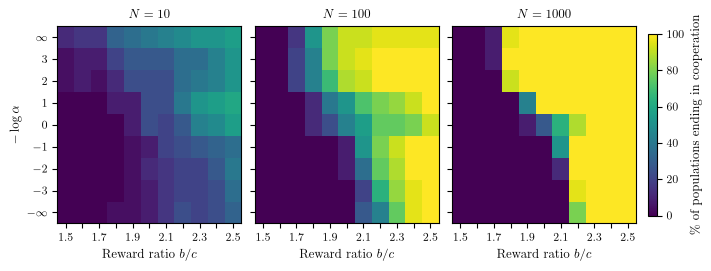

In [9]:
# Figure S9 (scripts/figures/figS09_basin_heatmaps.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

with np.load(DATA_DIR / "basin.npz") as data:
    bc_ratios, alphas = data["bc_ratios"], data["alphas"]
    agent_counts, grids = data["agent_counts"], data["cooperation_fraction"]

shown = (bc_ratios >= 1.5 - 1e-9) & (bc_ratios <= 2.5 + 1e-9)
bc_shown = bc_ratios[shown]
half_step = float(np.mean(np.diff(bc_shown))) / 2
bc_edges = [bc_shown[0] - half_step, bc_shown[-1] + half_step]
# Rows run from alpha = 1e6 (a point mass at the mean rate, -log alpha = -infinity) to
# alpha = 0 (equal point masses at 0.01 and 0.39, -log alpha = +infinity); logs are base 10.
alpha_labels = [
    r"$-\infty$" if np.isclose(alpha, 1e6) else r"$\infty$" if np.isclose(alpha, 0.0)
    else rf"${int(np.round(np.log10(1 / alpha)))}$"
    for alpha in alphas[::-1]
]

configure_paper_style()
fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 2.6), sharey=True)
for ax, num_agents, grid in zip(axes, agent_counts, grids, strict=True):
    image = ax.imshow(100 * grid[::-1, :][:, shown], origin="lower", aspect="auto", vmin=0.0,
                      vmax=100.0, extent=[*bc_edges, -0.5, len(alphas) - 0.5],
                      interpolation="nearest")
    ax.set_xlim(bc_edges)
    # Label every other b/c value so the labels do not collide.
    ax.set_xticks(bc_shown, [f"{r:.1f}" if k % 2 == 0 else "" for k, r in enumerate(bc_shown)])
    ax.set(title=rf"$N = {num_agents}$", xlabel=r"Reward ratio $b/c$")
axes[0].set_ylabel(r"$-\log \alpha$")
axes[0].set_yticks(np.arange(len(alphas)), alpha_labels)
fig.colorbar(image, ax=axes, shrink=0.92, pad=0.02,
             label=r"\% of populations ending in cooperation")
fig.savefig(FIGURES_DIR / "heatmaps.pdf", dpi=300)

## Figure S10: Noisy gradient ascent with uniform learning rates

Data: `agent_noise.npz` from `scripts/generate/agent_noise_data.py`.

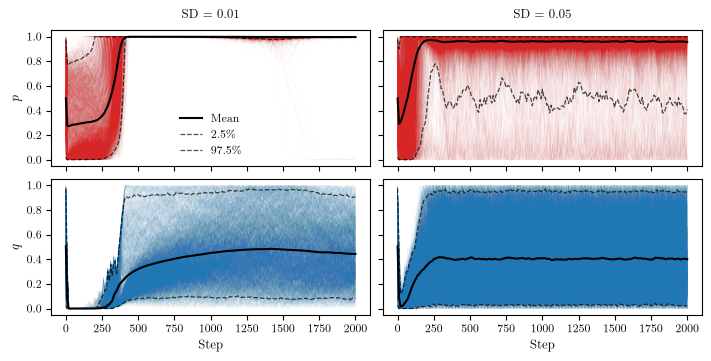

In [10]:
# Figure S10 (scripts/figures/figS10_noisy_population.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style, tsplot_runs

with np.load(DATA_DIR / "agent_noise.npz") as data:
    steps = data["steps"]
    runs = [(data["low_noise_agents"], float(data["low_noise_sd"])),
            (data["high_noise_agents"], float(data["high_noise_sd"]))]

configure_paper_style()
fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH, 3.5), sharex=True, sharey=True)
for column, (agents, noise_sd) in enumerate(runs):
    for row, color in enumerate(["C3", "C0"]):  # p (top), q (bottom)
        # agents has shape (saved step, agent, p/q); every agent is one thin line.
        tsplot_runs(steps, agents[:, :, row].T, color=color, ax=axes[row, column],
                    label_runs=(row, column) == (0, 0), line_alpha=0.03)
    axes[0, column].set_title(f"SD = {noise_sd:g}", pad=9)
    axes[1, column].set_xlabel("Step")
axes[0, 0].set_ylabel(r"$p$")
axes[1, 0].set_ylabel(r"$q$")
for ax in axes.ravel():
    ax.set_ylim(-0.05, 1.05)
axes[0, 0].legend(frameon=False, loc="lower center")

fig.savefig(FIGURES_DIR / "agent_based_dist_noisy_runs.pdf", dpi=300)

## Figure S11: An isolated pair of noisy learners

Data: `agent_pairs.npz` from `scripts/generate/agent_pair_data.py`.

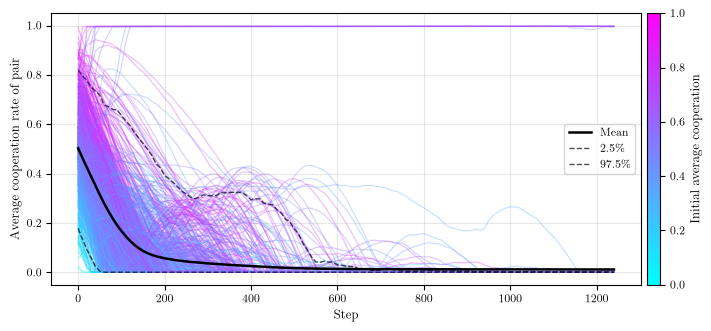

In [11]:
# Figure S11 (scripts/figures/figS11_noisy_pair.py)
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import configure_paper_style, plot_avg_coop_runs

with np.load(DATA_DIR / "agent_pairs.npz") as data:
    cooperation, steps = data["average_cooperation"], data["steps"]

configure_paper_style()
# First 125 saved steps (steps 0-1240) of every replicate pair.
fig, ax = plot_avg_coop_runs(cooperation[:, :125], x=steps[:125], cmap_name="cool")
ax.set_ylim(-0.05, 1.05)
fig.savefig(FIGURES_DIR / "avg_coop_two_agents_noisy.pdf", dpi=300)